# KSP 7.0 — Gravitational Lensing: Computational Solutions
**Krittika IIT Bombay | Selection Assignment | May 2026**

---

| Part | Task |
|------|------|
| (a) | Classical thin-lens optics |
| (b) | Gravitational lensing theory — exact vs approximate, error analysis, magnification |
| (c) | Single point-source lensing: four geometries |
| (d) | Extended disk source: distortion and magnification map |
| (e) | Einstein ring formation sequence |
| (f) | Inverse source reconstruction from CSV |
| (g) | De-lensing a simulated Einstein ring image |
| Val | Numerical validation: hyperbolic scattering + Hohmann transfer |

Run **Kernel → Restart & Run All** for clean top-to-bottom execution.  
Data files are in `data/`; figures save to `output/`.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
from scipy.integrate import solve_ivp
import cv2, os

np.random.seed(1729)
plt.rcParams.update({
    'axes.labelsize': 11, 'axes.titlesize': 12,
    'legend.fontsize': 9,  'figure.dpi': 110,
    'xtick.labelsize': 9,  'ytick.labelsize': 9,
    'figure.facecolor': 'white',
})
plt.style.use('seaborn-v0_8-paper')
os.makedirs('output', exist_ok=True)

c     = 2.998e8    # m/s
G     = 6.674e-11  # m^3 kg^-1 s^-2
M_sun = 1.989e30   # kg

# Galactic microlensing geometry (parts b-f):
# ~1 M_sun compact lens at 4 kpc; source star at 8 kpc (galactic centre).
# Representative of OGLE/KMTNet survey events.
# dLS = dS - dL  (flat geometry; cosmological correction <0.5% at these distances)
kpc = 3.0857e19     # m per kpc
dL  = 4.0 * kpc    # lens distance: 4 kpc
dS  = 8.0 * kpc    # source distance: 8 kpc
dLS = dS - dL      # 4 kpc  [dLS < dS — physically required]

print("Galactic microlensing scenario:")
print(f"  d_L  = {dL:.3e} m  ({dL/kpc:.1f} kpc)")
print(f"  d_S  = {dS:.3e} m  ({dS/kpc:.1f} kpc)")
print(f"  d_LS = {dLS:.3e} m  ({dLS/kpc:.1f} kpc)  [d_LS/d_S = {dLS/dS:.2f} < 1 ✓]")

Galactic microlensing scenario:
  d_L  = 1.234e+20 m  (4.0 kpc)
  d_S  = 2.469e+20 m  (8.0 kpc)
  d_LS = 1.234e+20 m  (4.0 kpc)  [d_LS/d_S = 0.50 < 1 ✓]


---
## Part (a): Classical Thin Lens

The thin convex lens maps an object at axial distance $x_0$ (from the lens plane)
to an image at $x_i$ via:

$$\frac{1}{x_i} = \frac{1}{f} - \frac{1}{x_0}, \qquad m = -\frac{x_i}{x_0}$$

Sign convention: distances are positive to the right of the lens.
For a real object ($x_0 > 0$), real images form at $x_i > 0$ when $x_0 > f$.

    (x0, y0)             (xi, yi)         Notes
──────────────────────────────────────────────────────────────
(-3.0, +0.8)        (+0.750, +0.200)        m=0.250  [virtual, upright]
(-2.0, +0.5)        (+0.667, +0.167)        m=0.333  [virtual, upright]
(-1.5, +0.6)        (+0.600, +0.240)        m=0.400  [virtual, upright]
(-0.6, +0.4)        (+0.375, +0.250)        m=0.625  [virtual, upright]


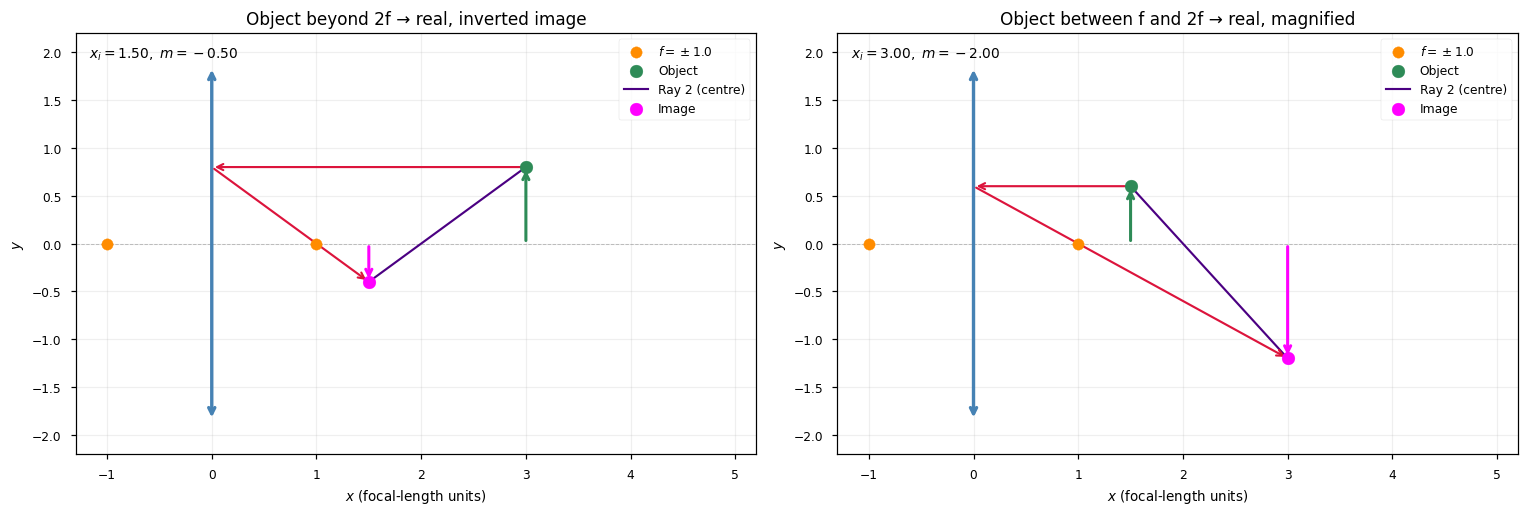

In [2]:
\
def thin_lens_image(x0, y0, f=1.0):
    if abs(x0) < 1e-14:
        return None, None
    inv = 1.0/f - 1.0/x0
    if abs(inv) < 1e-14:
        return np.inf, np.inf
    xi = 1.0 / inv
    return xi, (-xi / x0) * y0


def ray_diagram(x0, y0, f=1.0, ax=None, title=""):
    if ax is None:
        _, ax = plt.subplots(figsize=(9, 4.5))
    xi, yi = thin_lens_image(x0, y0, f)
    xhi = max(xi if (xi and xi != np.inf) else 4.0, 4.0) * 1.3
    ax.set_xlim(min(x0, -f) * 1.3, xhi)
    ax.set_ylim(-2.2, 2.2)
    ax.axhline(0, color='gray', lw=0.6, ls='--', alpha=0.5)
    ax.annotate('', xy=(0, 1.85), xytext=(0, -1.85),
                arrowprops=dict(arrowstyle='<->', color='steelblue', lw=2.2))
    ax.scatter([f, -f], [0, 0], color='darkorange', s=55, zorder=5, label=f'$f=\\pm{f}$')
    ax.annotate('', xy=(x0, y0), xytext=(x0, 0),
                arrowprops=dict(arrowstyle='->', color='seagreen', lw=2))
    ax.scatter([x0], [y0], color='seagreen', s=70, zorder=6, label='Object')
    if xi is not None and xi != np.inf:
        ax.annotate('', xy=(0, y0), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.4))
        ax.annotate('', xy=(xi, yi), xytext=(0, y0),
                    arrowprops=dict(arrowstyle='->', color='crimson', lw=1.4, label='Ray 1'))
        ax.plot([x0, xi], [y0, yi], color='indigo', lw=1.4, label='Ray 2 (centre)')
        ax.annotate('', xy=(xi, yi), xytext=(xi, 0),
                    arrowprops=dict(arrowstyle='->', color='magenta', lw=2))
        ax.scatter([xi], [yi], color='magenta', s=70, zorder=6, label='Image')
        ax.text(0.02, 0.97, f'$x_i={xi:.2f},\\ m={-xi/x0:.2f}$',
                transform=ax.transAxes, va='top', fontsize=9)
    ax.set_xlabel('$x$ (focal-length units)'); ax.set_ylabel('$y$')
    ax.set_title(title, fontsize=11); ax.legend(fontsize=8); ax.grid(alpha=0.2)
    return ax


cases = [(-3.0, 0.8), (-2.0, 0.5), (-1.5, 0.6), (-0.6, 0.4)]
print(f"{'(x0, y0)':^16}  {'(xi, yi)':^22}  Notes")
print("─" * 62)
for x0, y0 in cases:
    xi, yi = thin_lens_image(x0, y0)
    m = -xi/x0 if xi is not None and xi != np.inf else None
    region = "real, inverted" if m and m < 0 else "virtual, upright"
    xi_s = f"{xi:+.3f}" if xi != np.inf else "∞"
    yi_s = f"{yi:+.3f}" if yi != np.inf else "∞"
    print(f"({x0:+.1f}, {y0:+.1f}){'':6}  ({xi_s}, {yi_s}){'':6}  m={m:.3f}  [{region}]")

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
ray_diagram(3.0, 0.8, ax=axes[0], title='Object beyond 2f → real, inverted image')
ray_diagram(1.5, 0.6, ax=axes[1], title='Object between f and 2f → real, magnified')
plt.tight_layout()
plt.savefig('output/parta_thin_lens.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part (b): Gravitational Lensing Theory

For a point-mass lens $M$ at $d_L$, the Einstein angle is:

$$\theta_E = \sqrt{\frac{4GM}{c^2}\cdot\frac{d_{LS}}{d_L\,d_S}}$$

The lens equation $\theta^2 - \beta\theta - \theta_E^2 = 0$ has two solutions:

$$\theta_\pm = \frac{\beta \pm \sqrt{\beta^2 + 4\theta_E^2}}{2}$$

The approximate form $\theta_+ \approx \beta + \theta_E^2/\beta$ holds for $\beta \gg \theta_E$.
Total magnification:

$$\mu = \frac{u^2+2}{u\sqrt{u^2+4}}, \quad u \equiv \beta/\theta_E$$

**Scenario here:** Galaxy-scale strong lensing — a $10^{12}\,M_\odot$ elliptical at 1 Gpc
lensing a background quasar at 2.5 Gpc. This gives $\theta_E \approx 2$ arcsec,
consistent with observed strong-lensing systems (e.g.\ SDP.81, RX J1131).

Strong lensing scenario:
  d_L=1.0 Gpc, d_S=2.5 Gpc, d_LS=1.5 Gpc
  theta_E = 1.0718e-05 rad  =  2.21 arcsec


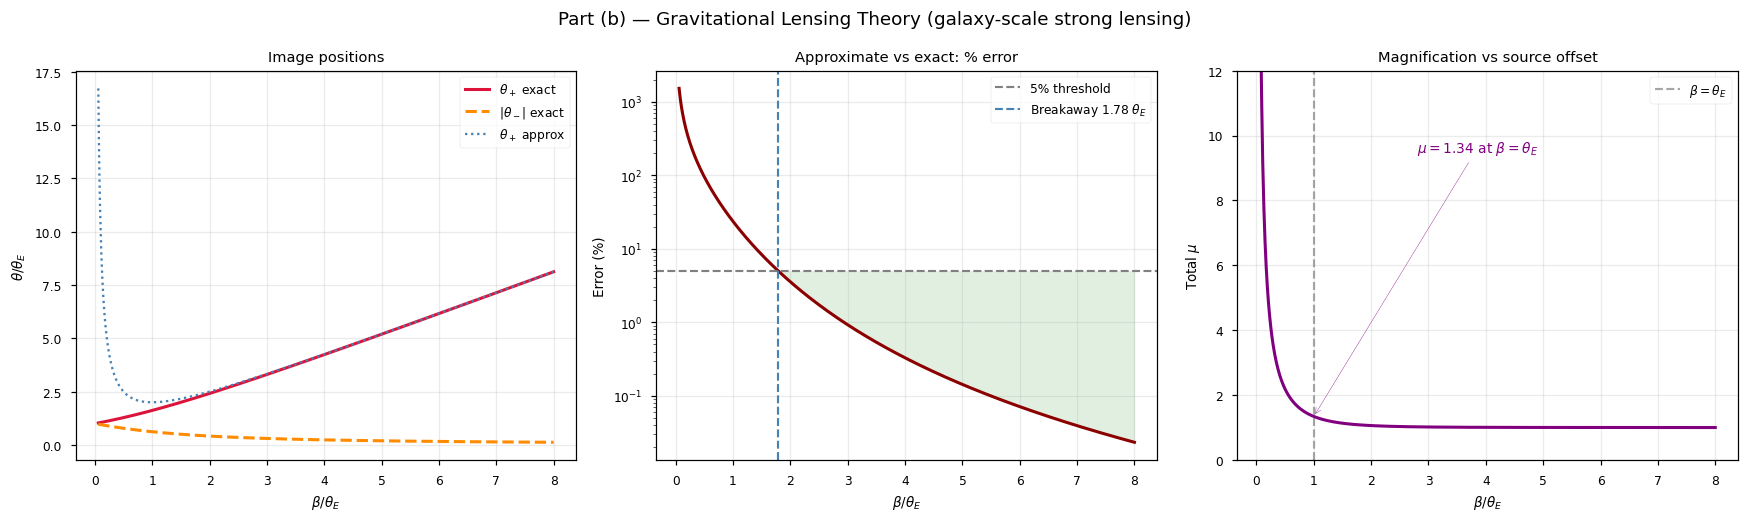

5% approximation breakaway: beta/theta_E = 1.779


In [3]:
\
def compute_thetaE(M, dL_in, dLS_in, dS_in):
    return np.sqrt(4*G*M/c**2 * dLS_in/(dL_in*dS_in))

def solve_exact(beta, tE):
    disc = np.sqrt(beta**2 + 4*tE**2)
    return (beta + disc)/2, (beta - disc)/2

def mu_total(u):
    return (u**2 + 2) / (u * np.sqrt(u**2 + 4))


Gpc   = 3.0857e25
M_gal = 1e12 * M_sun
dL_b  = 1.0 * Gpc
dS_b  = 2.5 * Gpc
dLS_b = dS_b - dL_b       # 1.5 Gpc  [dLS_b < dS_b ✓]
tE_b  = compute_thetaE(M_gal, dL_b, dLS_b, dS_b)

print(f"Strong lensing scenario:")
print(f"  d_L={dL_b/Gpc:.1f} Gpc, d_S={dS_b/Gpc:.1f} Gpc, d_LS={dLS_b/Gpc:.1f} Gpc")
print(f"  theta_E = {tE_b:.4e} rad  =  {np.degrees(tE_b)*3600:.2f} arcsec")

beta_n = np.linspace(0.06, 8.0, 800)
tp_ex  = np.array([solve_exact(b*tE_b, tE_b)[0]/tE_b for b in beta_n])
tp_ap  = beta_n + 1.0/beta_n
pct    = np.abs(tp_ex - tp_ap) / tp_ex * 100
idx5   = np.searchsorted(pct[::-1], 5.0)
b_brk  = beta_n[len(beta_n)-1-idx5]
mu_arr = mu_total(beta_n)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

ax = axes[0]
tm_ex = np.abs([solve_exact(b*tE_b, tE_b)[1]/tE_b for b in beta_n])
ax.plot(beta_n, tp_ex,  lw=2.0, color='crimson',   label=r'$\theta_+$ exact')
ax.plot(beta_n, tm_ex,  lw=2.0, color='darkorange', ls='--', label=r'$|\theta_-|$ exact')
ax.plot(beta_n, tp_ap,  lw=1.5, color='steelblue',  ls=':', label=r'$\theta_+$ approx')
ax.set_xlabel(r'$\beta/\theta_E$'); ax.set_ylabel(r'$\theta/\theta_E$')
ax.set_title('Image positions'); ax.legend(); ax.grid(alpha=0.25)

ax = axes[1]
ax.semilogy(beta_n, pct, lw=2, color='darkred')
ax.axhline(5, color='gray', ls='--', label='5% threshold')
ax.axvline(b_brk, color='steelblue', ls='--', label=f'Breakaway {b_brk:.2f} $\\theta_E$')
ax.fill_between(beta_n, pct, 5, where=pct<5, alpha=0.12, color='green')
ax.set_xlabel(r'$\beta/\theta_E$'); ax.set_ylabel('Error (%)')
ax.set_title('Approximate vs exact: % error'); ax.legend(); ax.grid(alpha=0.25)

ax = axes[2]
ax.plot(beta_n, mu_arr, lw=2.0, color='purple')
ax.axvline(1.0, color='gray', ls='--', alpha=0.7, label=r'$\beta=\theta_E$')
ax.set_xlabel(r'$\beta/\theta_E$'); ax.set_ylabel(r'Total $\mu$')
ax.set_title('Magnification vs source offset'); ax.set_ylim(0, 12)
ax.annotate(fr'$\mu={mu_total(1.0):.2f}$ at $\beta=\theta_E$',
            xy=(1.0, mu_total(1.0)), xytext=(2.8, 9.5),
            arrowprops=dict(arrowstyle='->', color='purple'), fontsize=9, color='purple')
ax.legend(); ax.grid(alpha=0.25)

plt.suptitle('Part (b) — Gravitational Lensing Theory (galaxy-scale strong lensing)', fontsize=12)
plt.tight_layout()
plt.savefig('output/partb_lens_error.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"5% approximation breakaway: beta/theta_E = {b_brk:.3f}")

---
## Part (c): Single Point Source — Four Geometries

Microlensing scenario: $M = 1\,M_\odot$ at 4 kpc, source at 8 kpc.
$\theta_E \approx 1$ mas, consistent with OGLE survey events.

Microlensing theta_E = 4.8920e-09 rad  =  1.009 mas


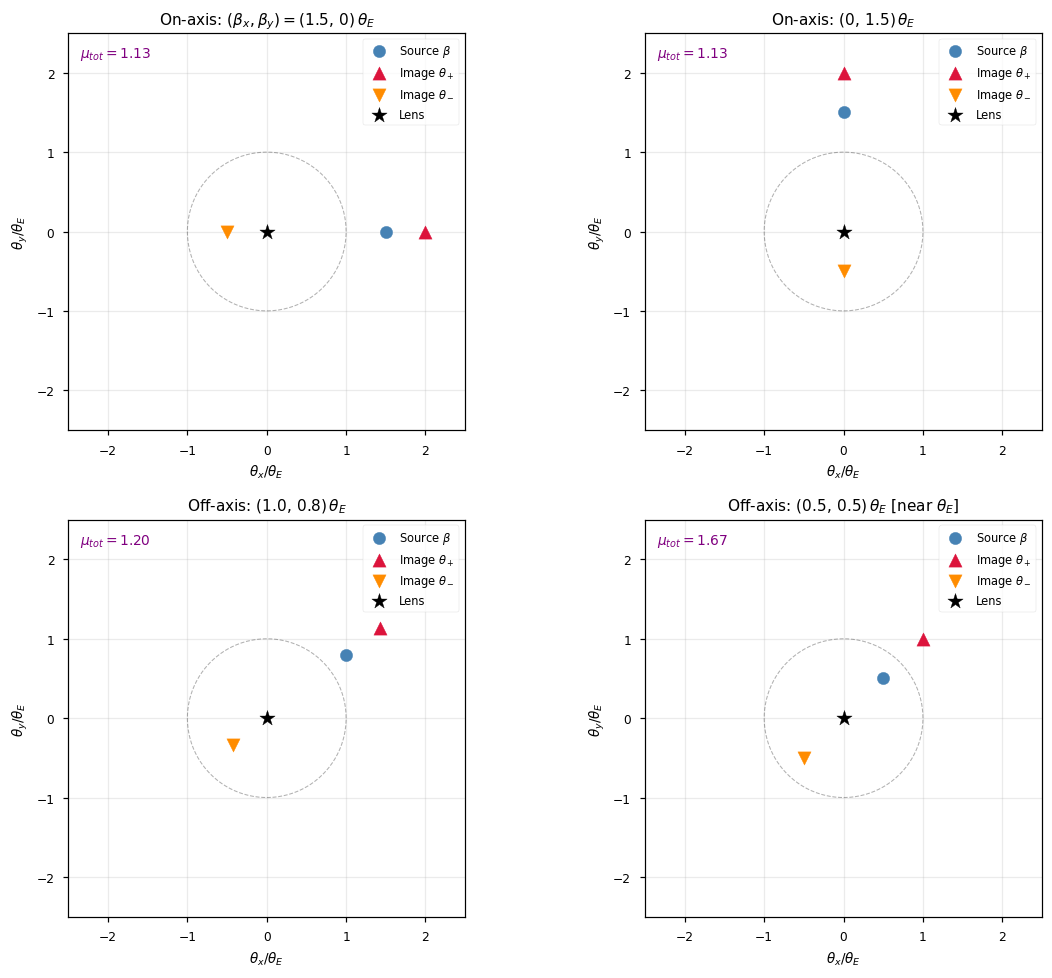

In [4]:
\
tE = compute_thetaE(M_sun, dL, dLS, dS)
print(f"Microlensing theta_E = {tE:.4e} rad  =  {np.degrees(tE)*3600*1e3:.3f} mas")


def lens_2d(bx, by, tE_v):
    beta = np.hypot(bx, by)
    if beta < 1e-12 * tE_v:
        return (0.0, tE_v), (0.0, -tE_v)
    disc = np.sqrt(beta**2 + 4*tE_v**2)
    tp, tm = (beta + disc)/2, (beta - disc)/2
    ux, uy = bx/beta, by/beta
    return (ux*tp, uy*tp), (ux*tm, uy*tm)


cases = [
    (1.5*tE, 0.0,        r'On-axis: $(\beta_x,\beta_y)=(1.5,\,0)\,\theta_E$'),
    (0.0,    1.5*tE,     r'On-axis: $(0,\,1.5)\,\theta_E$'),
    (1.0*tE, 0.8*tE,     r'Off-axis: $(1.0,\,0.8)\,\theta_E$'),
    (0.5*tE, 0.5*tE,     r'Off-axis: $(0.5,\,0.5)\,\theta_E$ [near $\theta_E$]'),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
phi_r = np.linspace(0, 2*np.pi, 200)
for ax, (bx, by, lbl) in zip(axes.flat, cases):
    ip, im = lens_2d(bx, by, tE)
    ax.scatter([bx/tE], [by/tE], s=65, color='steelblue', zorder=6, label=r'Source $\beta$')
    ax.scatter([ip[0]/tE], [ip[1]/tE], s=75, color='crimson',
               marker='^', zorder=6, label=r'Image $\theta_+$')
    ax.scatter([im[0]/tE], [im[1]/tE], s=75, color='darkorange',
               marker='v', zorder=6, label=r'Image $\theta_-$')
    ax.scatter([0], [0], s=110, color='black', marker='*', zorder=7, label='Lens')
    ax.plot(np.cos(phi_r), np.sin(phi_r), 'k--', lw=0.7, alpha=0.3)
    bn = np.hypot(bx, by)/tE
    ax.text(0.03, 0.97, fr'$\mu_{{tot}}={mu_total(bn):.2f}$',
            transform=ax.transAxes, va='top', fontsize=9, color='purple')
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_xlabel(r'$\theta_x/\theta_E$'); ax.set_ylabel(r'$\theta_y/\theta_E$')
    ax.set_title(lbl, fontsize=10); ax.legend(fontsize=7.5); ax.grid(alpha=0.25)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('output/partc_single_source.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part (d): Extended Source Lensing

Circular source of radius $0.3\,\theta_E$ centred at $(1.2,\,0.6)\,\theta_E$,
sampled with $N=300$ uniform points. Each point lensed independently.
The major image arc elongates tangentially; the minor arc is more compact.

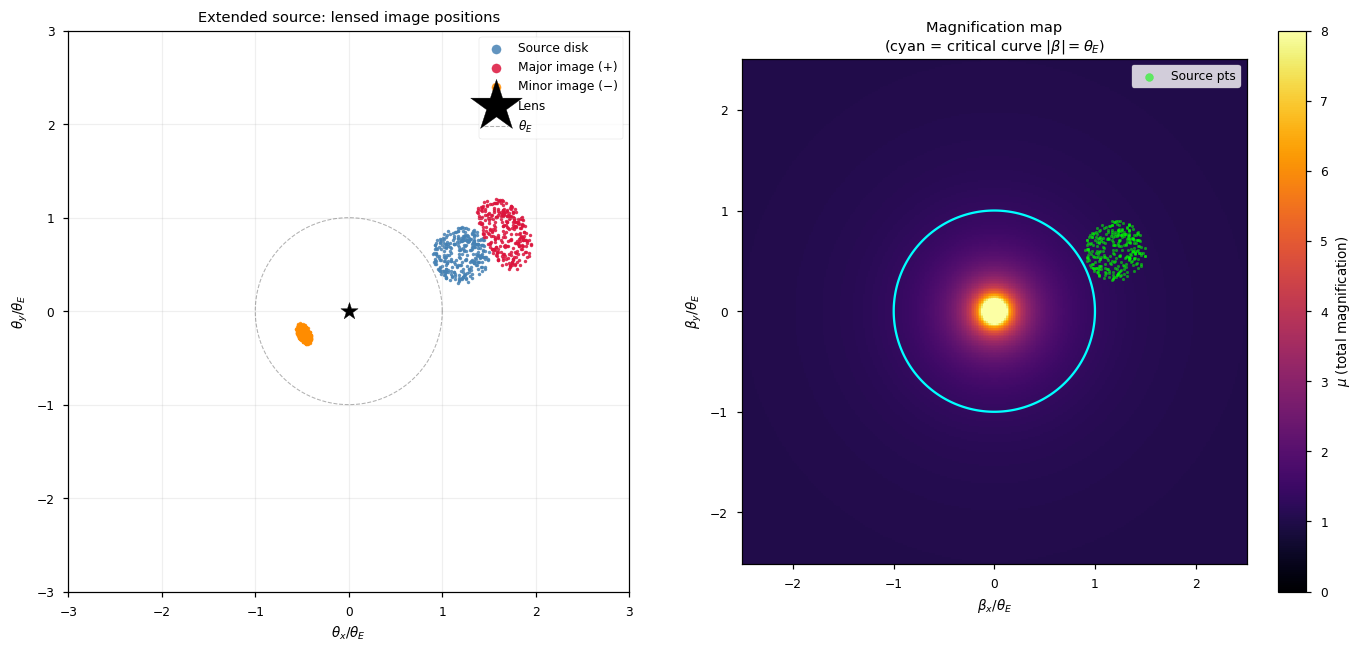

Source: R=0.3 tE  centre=(1.2,0.6) tE
Major image spread: dx=0.570, dy=0.753 [tE]
Minor image spread: dx=0.161, dy=0.222 [tE]


In [5]:
\
np.random.seed(1729)
N_pts = 300
cx0, cy0, Rsrc = 1.2, 0.6, 0.3   # units of tE

r_r   = np.sqrt(np.random.uniform(0, 1, N_pts)) * Rsrc
phi_r = np.random.uniform(0, 2*np.pi, N_pts)
bx_arr = (cx0 + r_r*np.cos(phi_r)) * tE
by_arr = (cy0 + r_r*np.sin(phi_r)) * tE

ip_x, ip_y, im_x, im_y = [], [], [], []
for bx, by in zip(bx_arr, by_arr):
    ip, im = lens_2d(bx, by, tE)
    ip_x.append(ip[0]); ip_y.append(ip[1])
    im_x.append(im[0]); im_y.append(im[1])

ip_x = np.array(ip_x)/tE; ip_y = np.array(ip_y)/tE
im_x = np.array(im_x)/tE; im_y = np.array(im_y)/tE
bx_n = bx_arr/tE; by_n = by_arr/tE

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
phi_ring = np.linspace(0, 2*np.pi, 300)

ax = axes[0]
ax.scatter(bx_n, by_n, s=4, color='steelblue', alpha=0.85, label='Source disk')
ax.scatter(ip_x, ip_y, s=4, color='crimson',    alpha=0.85, label='Major image (+)')
ax.scatter(im_x, im_y, s=4, color='darkorange', alpha=0.85, label='Minor image (−)')
ax.scatter([0], [0], s=140, color='black', marker='*', zorder=7, label='Lens')
ax.plot(np.cos(phi_ring), np.sin(phi_ring), 'k--', lw=0.7, alpha=0.3, label=r'$\theta_E$')
ax.set_xlim(-3, 3); ax.set_ylim(-3, 3)
ax.set_xlabel(r'$\theta_x/\theta_E$'); ax.set_ylabel(r'$\theta_y/\theta_E$')
ax.set_title('Extended source: lensed image positions')
ax.legend(markerscale=3); ax.grid(alpha=0.2); ax.set_aspect('equal')

# Magnification map
ax = axes[1]
bg = np.linspace(-2.5, 2.5, 300)
BXg, BYg = np.meshgrid(bg, bg)
Ug = np.hypot(BXg, BYg)
Ug_safe = np.where(Ug < 0.05, 0.05, Ug)
MUg = np.clip(mu_total(Ug_safe), 0, 12)
im2 = ax.pcolormesh(BXg, BYg, MUg, cmap='inferno', shading='auto', vmin=0, vmax=8)
plt.colorbar(im2, ax=ax, label=r'$\mu$ (total magnification)')
ax.contour(BXg, BYg, Ug, levels=[1.0], colors='cyan', linewidths=1.5)
ax.scatter(bx_n, by_n, s=3, color='lime', alpha=0.55, label='Source pts')
ax.set_xlabel(r'$\beta_x/\theta_E$'); ax.set_ylabel(r'$\beta_y/\theta_E$')
ax.set_title('Magnification map\n(cyan = critical curve $|\\beta|=\\theta_E$)')
ax.legend(markerscale=3, fontsize=8); ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('output/partd_extended_source.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Source: R={Rsrc} tE  centre=({cx0},{cy0}) tE")
print(f"Major image spread: dx={np.ptp(ip_x):.3f}, dy={np.ptp(ip_y):.3f} [tE]")
print(f"Minor image spread: dx={np.ptp(im_x):.3f}, dy={np.ptp(im_y):.3f} [tE]")

---
## Part (e): Einstein Ring Formation

As $\beta_y \to 0$ (source approaching the optical axis), the two images merge
into a complete ring of radius $\theta_E$.

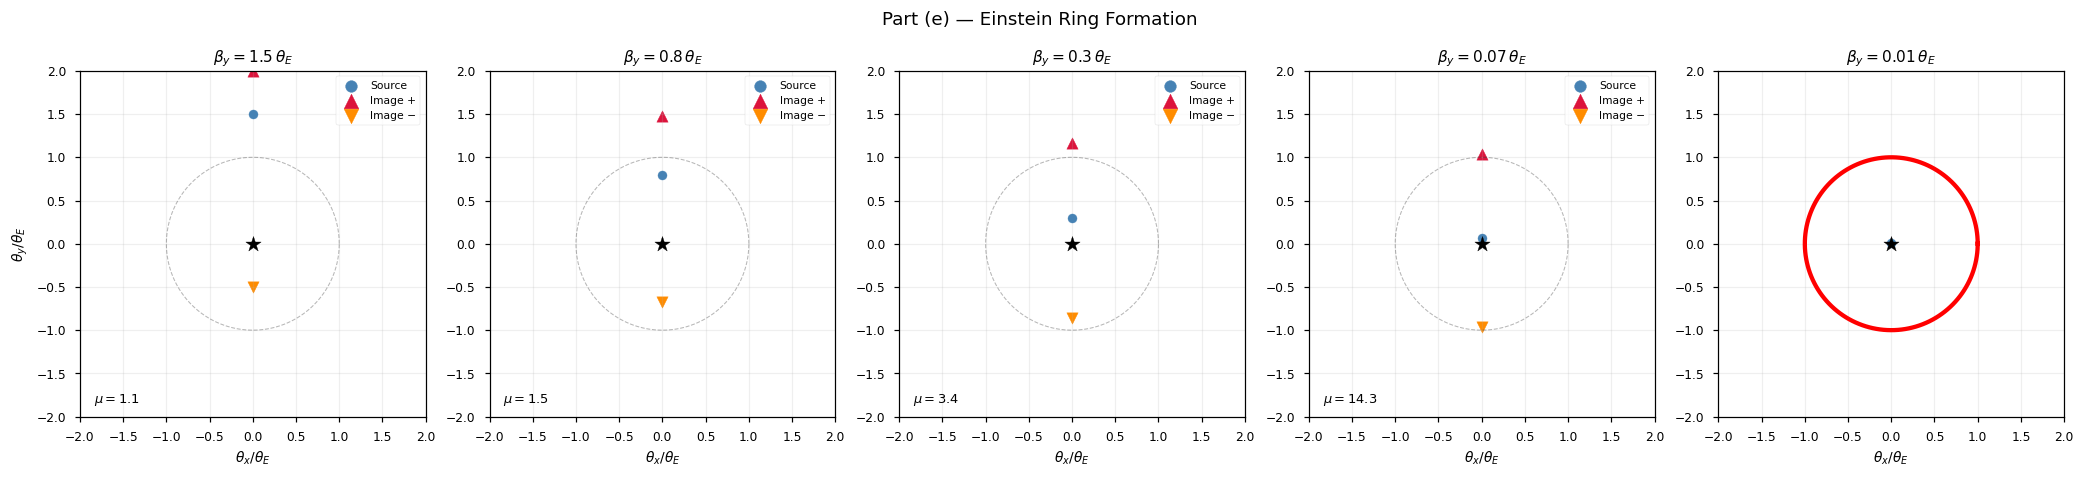

In [6]:
\
y_vals = [1.5, 0.8, 0.3, 0.07, 0.01]
fig, axes = plt.subplots(1, 5, figsize=(19, 4.2))

for ax, yv in zip(axes, y_vals):
    phi_r = np.linspace(0, 2*np.pi, 300)
    ax.plot(np.cos(phi_r), np.sin(phi_r), 'k--', lw=0.7, alpha=0.28)
    ax.scatter([0], [0], s=110, color='black', marker='*', zorder=7)
    if yv < 0.04:
        ax.plot(np.cos(phi_r), np.sin(phi_r), 'r-', lw=2.8, label='Einstein ring')
        ax.scatter([0], [yv], s=35, color='steelblue', zorder=6)
    else:
        ip, im = lens_2d(0.0, yv*tE, tE)
        ax.scatter([0], [yv], s=35, color='steelblue', zorder=6, label='Source')
        ax.scatter([ip[0]/tE], [ip[1]/tE], s=55, color='crimson',
                   marker='^', label='Image +')
        ax.scatter([im[0]/tE], [im[1]/tE], s=55, color='darkorange',
                   marker='v', label='Image −')
        ax.text(0.04, 0.04, fr'$\mu={mu_total(yv):.1f}$',
                transform=ax.transAxes, fontsize=8.5)
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2); ax.set_aspect('equal')
    ax.set_title(fr'$\beta_y={yv}\,\theta_E$', fontsize=10)
    ax.set_xlabel(r'$\theta_x/\theta_E$', fontsize=9)
    if ax is axes[0]: ax.set_ylabel(r'$\theta_y/\theta_E$', fontsize=9)
    if yv >= 0.04: ax.legend(fontsize=7, markerscale=1.3, loc='upper right')
    ax.grid(alpha=0.2)

fig.suptitle('Part (e) — Einstein Ring Formation', fontsize=12)
plt.tight_layout()
plt.savefig('output/parte_einstein_ring.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part (f): Source Reconstruction (Inverse Lensing)

The lens equation inverts algebraically:

$$\frac{\boldsymbol{\beta}}{\theta_E} = \frac{\boldsymbol{\theta}}{\theta_E}
\!\left(1 - \frac{1}{|\boldsymbol{\theta}/\theta_E|^2}\right)$$

Applied independently to the two image positions of each pair, both must recover the
same $\boldsymbol{\beta}$. The reconstruction residual is therefore a numerical
consistency check — it should be at the level of floating-point round-off ($\sim 10^{-8}\,\theta_E$).

Loaded: 800 rows | columns: ['beta_x/theta_E', 'beta_y/theta_E', 'theta1_x/theta_E', 'theta1_y/theta_E', 'theta2_x/theta_E', 'theta2_y/theta_E']
   beta_x/theta_E  beta_y/theta_E  theta1_x/theta_E  theta1_y/theta_E  theta2_x/theta_E  theta2_y/theta_E
0        0.806297        0.345087          1.406997          0.602181         -0.600700         -0.257093
1        0.849654        0.364442          1.437292          0.616498         -0.587638         -0.252056
2        0.878076        0.401669          1.448846          0.662763         -0.570769         -0.261094

Reconstruction residuals (theta_E units):
  Mean : 1.133e-08
  Max  : 3.155e-08
  (Floating-point noise; algebraically exact inverse ✓)


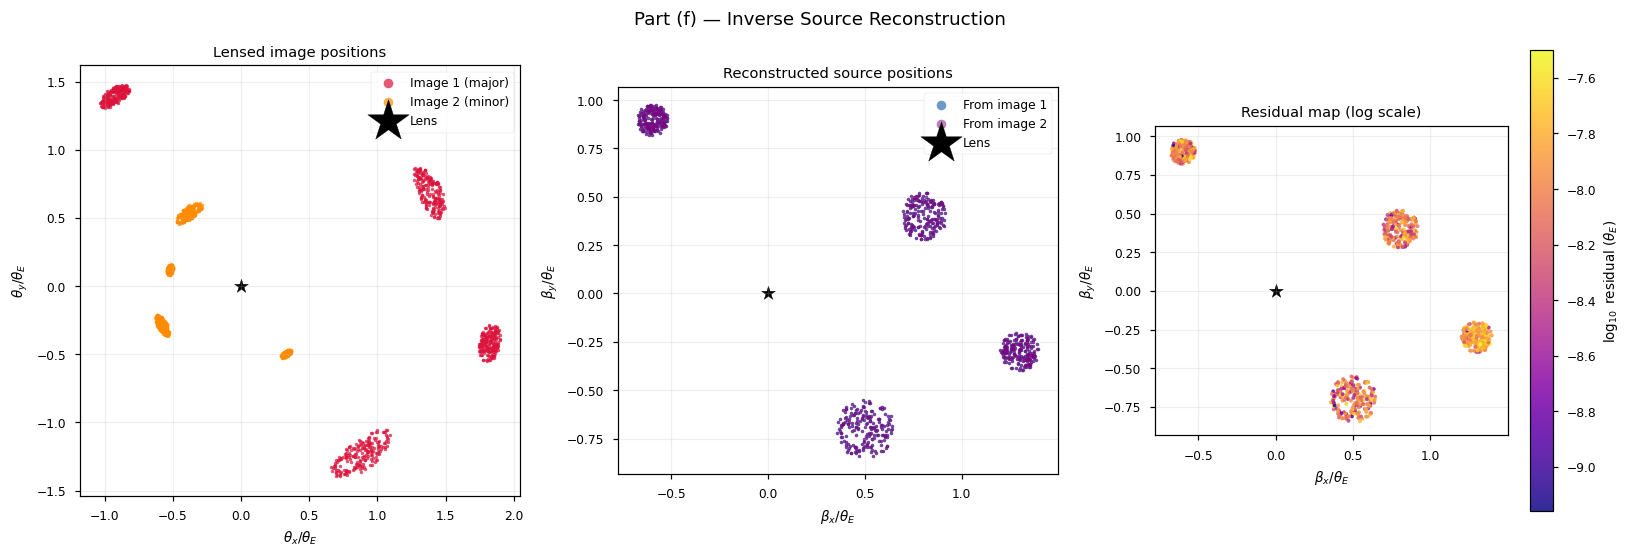

In [7]:
\
df = pd.read_csv('data/lensed_points.csv')
print(f"Loaded: {df.shape[0]} rows | columns: {df.columns.tolist()}")
print(df.head(3).to_string())

def inverse_lens(tx_n, ty_n):
    th2 = np.maximum(tx_n**2 + ty_n**2, 1e-12)
    f   = 1.0 - 1.0 / th2
    return tx_n * f, ty_n * f

tx1 = df['theta1_x/theta_E'].values; ty1 = df['theta1_y/theta_E'].values
tx2 = df['theta2_x/theta_E'].values; ty2 = df['theta2_y/theta_E'].values

bx1, by1 = inverse_lens(tx1, ty1)
bx2, by2 = inverse_lens(tx2, ty2)
res = np.hypot(bx1 - bx2, by1 - by2)

print(f"\nReconstruction residuals (theta_E units):")
print(f"  Mean : {res.mean():.3e}")
print(f"  Max  : {res.max():.3e}")
print(f"  (Floating-point noise; algebraically exact inverse ✓)")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.scatter(tx1, ty1, s=4, color='crimson',    alpha=0.7, label='Image 1 (major)')
ax.scatter(tx2, ty2, s=4, color='darkorange', alpha=0.7, label='Image 2 (minor)')
ax.scatter([0], [0], s=90, color='black', marker='*', label='Lens')
ax.set_title('Lensed image positions')
ax.set_xlabel(r'$\theta_x/\theta_E$'); ax.set_ylabel(r'$\theta_y/\theta_E$')
ax.legend(markerscale=3); ax.grid(alpha=0.2); ax.set_aspect('equal')

ax = axes[1]
ax.scatter(bx1, by1, s=4, color='steelblue', alpha=0.8, label='From image 1')
ax.scatter(bx2, by2, s=4, color='purple',    alpha=0.5, label='From image 2')
ax.scatter([0], [0], s=90, color='black', marker='*', label='Lens')
ax.set_title('Reconstructed source positions')
ax.set_xlabel(r'$\beta_x/\theta_E$'); ax.set_ylabel(r'$\beta_y/\theta_E$')
ax.legend(markerscale=3); ax.grid(alpha=0.2); ax.set_aspect('equal')

ax = axes[2]
sc = ax.scatter(bx1, by1, c=np.log10(res + 1e-16), cmap='plasma', s=5, alpha=0.85)
plt.colorbar(sc, ax=ax, label=r'$\log_{10}$ residual ($\theta_E$)')
ax.scatter([0], [0], s=90, color='k', marker='*')
ax.set_title('Residual map (log scale)')
ax.set_xlabel(r'$\beta_x/\theta_E$'); ax.set_ylabel(r'$\beta_y/\theta_E$')
ax.grid(alpha=0.2); ax.set_aspect('equal')

plt.suptitle('Part (f) — Inverse Source Reconstruction', fontsize=12)
plt.tight_layout()
plt.savefig('output/partf_reconstruction.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part (g): De-lensing a Simulated Einstein Ring

We apply the inverse lensing map to a numerically simulated Einstein ring image.
For each pixel $(\beta_x, \beta_y)$ in the output (source plane), the forward lens
map gives the corresponding image-plane position $(\theta_x, \theta_y)$; the
image brightness there is fetched via bicubic interpolation.

Image: 512x512 px


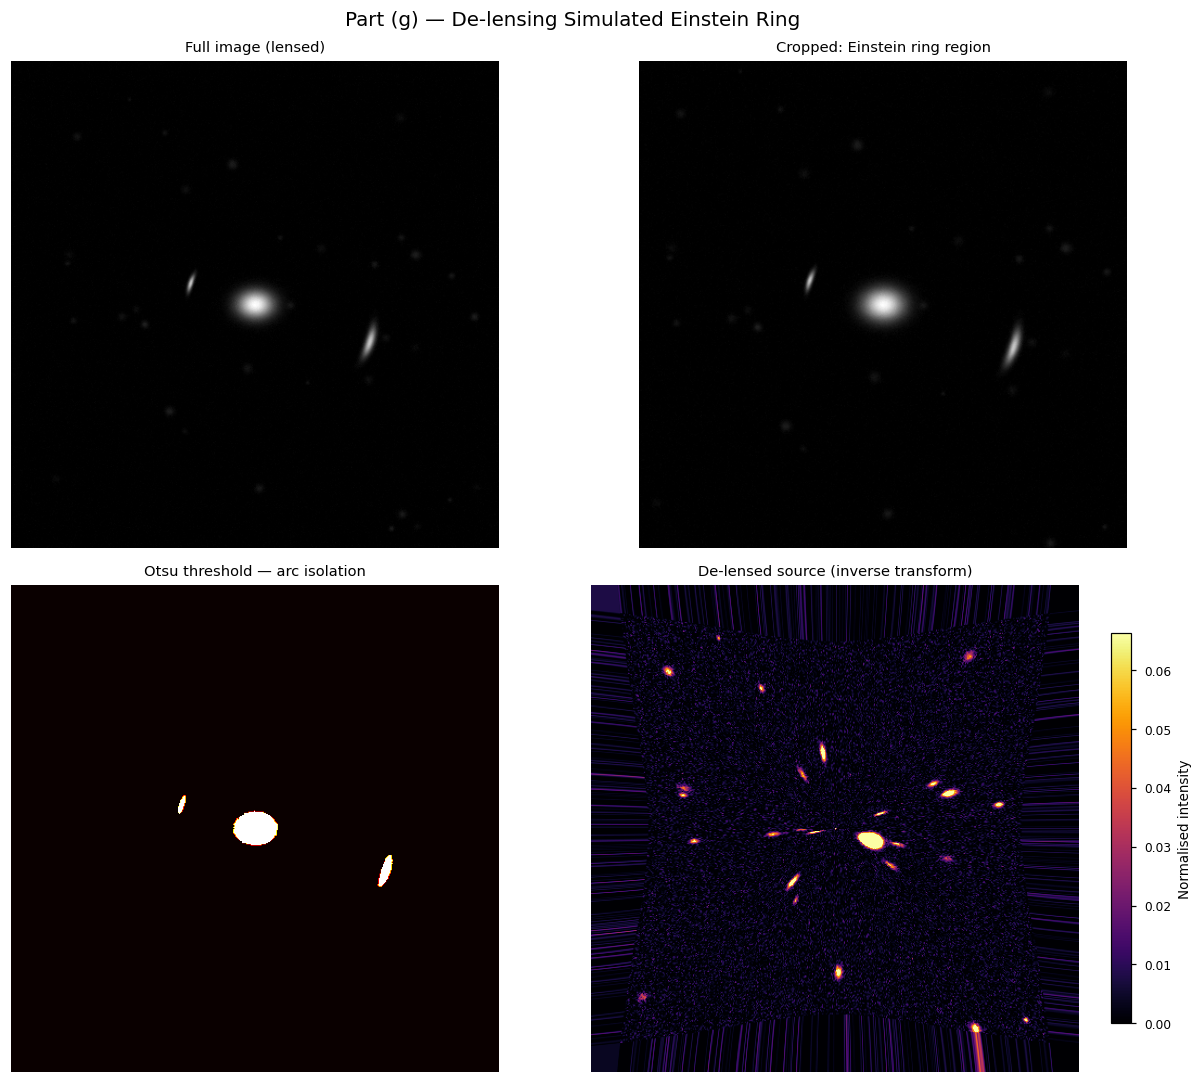

De-lensed: peak=0.9922, non-zero px=1932


In [8]:
\
img_bgr = cv2.imread('data/simulated_lensed_galaxy.bmp')
if img_bgr is None:
    raise FileNotFoundError("data/simulated_lensed_galaxy.bmp not found.")
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
H, W     = img_gray.shape
print(f"Image: {W}x{H} px")

cx, cy   = W//2, H//2
crop_r   = int(min(H, W) * 0.44)
img_c    = img_gray[cy-crop_r:cy+crop_r, cx-crop_r:cx+crop_r]
img_c_rgb= img_rgb[cy-crop_r:cy+crop_r, cx-crop_r:cx+crop_r]
Hc, Wc   = img_c.shape

ring_r_px = crop_r * 0.48        # Einstein ring radius in pixels
scale     = 1.0 / ring_r_px      # pixel → theta/theta_E

ys = (np.arange(Hc) - Hc/2) * scale
xs = (np.arange(Wc) - Wc/2) * scale
BX, BY = np.meshgrid(xs, ys)

beta_arr  = np.hypot(BX, BY)
eps       = 1e-9
beta_safe = np.where(beta_arr < eps, eps, beta_arr)
theta_p   = (beta_safe + np.sqrt(beta_safe**2 + 4.0)) / 2.0
ux = np.where(beta_arr > eps, BX/beta_safe, 0.0)
uy = np.where(beta_arr > eps, BY/beta_safe, 0.0)

map_x = np.clip((ux*theta_p)/scale + Wc/2, 0, Wc-1)
map_y = np.clip((uy*theta_p)/scale + Hc/2, 0, Hc-1)
delensed = map_coordinates(img_c, [map_y, map_x], order=3, mode='constant', cval=0.0)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0,0].imshow(img_gray, cmap='gray', origin='upper')
axes[0,0].set_title('Full image (lensed)'); axes[0,0].axis('off')
axes[0,1].imshow(img_c_rgb, origin='upper')
axes[0,1].set_title('Cropped: Einstein ring region'); axes[0,1].axis('off')

_, mask = cv2.threshold((img_c*255).astype(np.uint8), 0, 255,
                         cv2.THRESH_BINARY + cv2.THRESH_OTSU)
axes[1,0].imshow(mask, cmap='hot', origin='upper')
axes[1,0].set_title('Otsu threshold — arc isolation'); axes[1,0].axis('off')

vmax_dl = np.percentile(delensed[delensed > 0.01], 97) if (delensed > 0.01).any() else 1.0
im_dl = axes[1,1].imshow(delensed, cmap='inferno', origin='upper', vmin=0, vmax=vmax_dl)
axes[1,1].set_title('De-lensed source (inverse transform)'); axes[1,1].axis('off')
plt.colorbar(im_dl, ax=axes[1,1], shrink=0.8, label='Normalised intensity')

plt.suptitle('Part (g) — De-lensing Simulated Einstein Ring', fontsize=13)
plt.tight_layout()
plt.savefig('output/partg_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"De-lensed: peak={delensed.max():.4f}, non-zero px={(delensed>0.02).sum()}")

---
## Critical Curve and Caustic — Point-Mass Lens

For a point-mass lens, the critical curve in the image plane is the Einstein ring
$|\boldsymbol{\theta}| = \theta_E$.  The corresponding caustic in the source plane
collapses to a single point at $\boldsymbol{\beta} = 0$, reflecting the cylindrical
symmetry of the mass distribution.  Extended or asymmetric lenses (SIS, NFW, binary)
produce finite-size caustics (astroid, fold arcs).

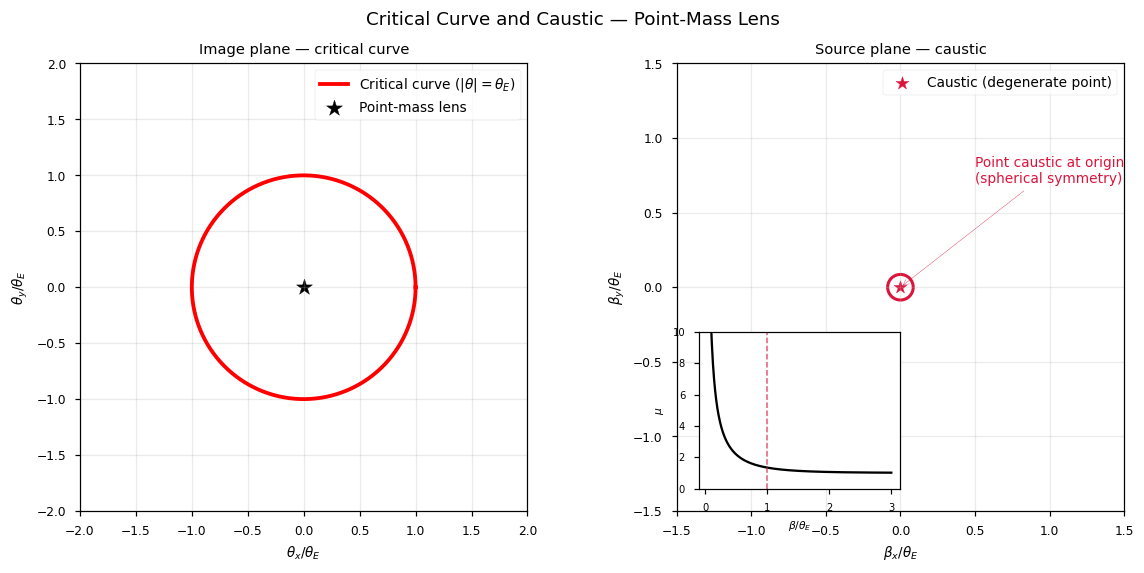

In [9]:
\
fig, axes = plt.subplots(1, 2, figsize=(11, 5.2))
phi = np.linspace(0, 2*np.pi, 400)

ax = axes[0]
ax.plot(np.cos(phi), np.sin(phi), 'r-', lw=2.5, label=r'Critical curve ($|\theta|=\theta_E$)')
ax.scatter([0], [0], s=120, color='black', marker='*', label='Point-mass lens')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_xlabel(r'$\theta_x/\theta_E$'); ax.set_ylabel(r'$\theta_y/\theta_E$')
ax.set_title('Image plane — critical curve')
ax.legend(fontsize=9); ax.grid(alpha=0.25); ax.set_aspect('equal')

ax = axes[1]
ax.scatter([0], [0], s=80, color='crimson', marker='*', label='Caustic (degenerate point)')
ax.scatter([0], [0], s=280, facecolors='none', edgecolors='crimson', lw=2)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_xlabel(r'$\beta_x/\theta_E$'); ax.set_ylabel(r'$\beta_y/\theta_E$')
ax.set_title('Source plane — caustic')
ax.legend(fontsize=9); ax.grid(alpha=0.25); ax.set_aspect('equal')
ax.annotate('Point caustic at origin\n(spherical symmetry)',
            xy=(0,0), xytext=(0.5, 0.7),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            fontsize=9, color='crimson')
ax2 = ax.inset_axes([0.05, 0.05, 0.45, 0.35])
b_arr = np.linspace(0.05, 3.0, 500)
ax2.plot(b_arr, mu_total(b_arr), 'k-', lw=1.5)
ax2.axvline(1.0, color='crimson', ls='--', lw=1, alpha=0.7)
ax2.set_xlabel(r'$\beta/\theta_E$', fontsize=7); ax2.set_ylabel(r'$\mu$', fontsize=7)
ax2.set_ylim(0, 10); ax2.tick_params(labelsize=6.5)

plt.suptitle('Critical Curve and Caustic — Point-Mass Lens', fontsize=12)
plt.tight_layout()
plt.savefig('output/caustic_critical.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Mission Trajectory: Earth → Jupiter → Neptune

Heliocentric plot of the full gravity-assist mission (Theory Q5).
Jupiter is shown at its position at the Hohmann arc endpoint (approximately 180°
from Earth), and Neptune at both launch and arrival.

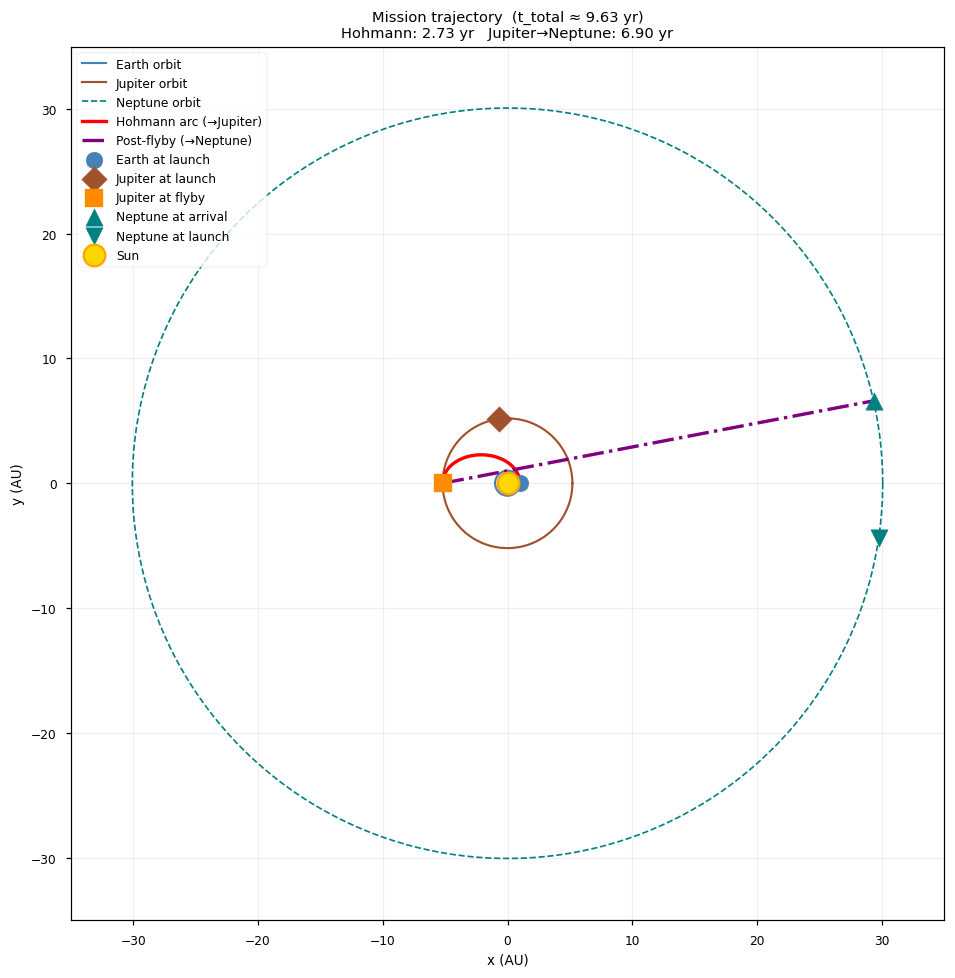

t1=2.7288 yr, t2=6.9008 yr, t_total=9.6296 yr


In [10]:
\
G_SI = 6.674e-11; M_sun_kg = 1.989e30; AU = 1.496e11; yr = 365.25*86400
GM_s = G_SI * M_sun_kg
RE = 1.0*AU; RJ = 5.2*AU; RN = 30.07*AU
TJ = 11.86*yr; TN = 164.8*yr

aT_h = (RE + RJ)/2
t1   = np.pi * np.sqrt(aT_h**3 / GM_s)   # Hohmann half-period

# Post-flyby velocity (verified in Q5)
vf_vec = np.array([23724.0, 4539.0])      # m/s, Jupiter-frame x = Jupiter velocity dir
P_J    = np.array([-RJ, 0.0])             # Jupiter at Hohmann aphelion (180 deg from Earth)

a_c = np.dot(vf_vec, vf_vec)
b_c = 2.0 * np.dot(P_J, vf_vec)
c_c = RJ**2 - RN**2
t2  = (-b_c + np.sqrt(b_c**2 - 4*a_c*c_c)) / (2*a_c)
t_tot = t1 + t2

P_N_arr    = P_J + vf_vec * t2
phi_N_arr  = np.arctan2(P_N_arr[1], P_N_arr[0])
phi_N_laun = phi_N_arr - 2*np.pi/TN * t_tot
phi_J_laun = np.pi - 2*np.pi/TJ * t1

fig, ax = plt.subplots(figsize=(9, 9))
tc = np.linspace(0, 2*np.pi, 400)

ax.plot(RE/AU*np.cos(tc), RE/AU*np.sin(tc), color='steelblue', lw=1.4, label='Earth orbit')
ax.plot(RJ/AU*np.cos(tc), RJ/AU*np.sin(tc), color='sienna',    lw=1.4, label='Jupiter orbit')
ax.plot(RN/AU*np.cos(tc), RN/AU*np.sin(tc), color='teal',      lw=1.1, ls='--', label='Neptune orbit')

ecc = (RJ-RE)/(RJ+RE)
th_H = np.linspace(0, np.pi, 200)
r_H = aT_h*(1-ecc**2)/(1+ecc*np.cos(th_H))
ax.plot(r_H/AU*np.cos(th_H), r_H/AU*np.sin(th_H), 'r-', lw=2.2, label='Hohmann arc (→Jupiter)')

t_fl = np.linspace(0, t2, 200)
traj = P_J[:,None] + vf_vec[:,None]*t_fl
ax.plot(traj[0]/AU, traj[1]/AU, color='purple', lw=2.2, ls='-.', label='Post-flyby (→Neptune)')

ax.scatter([RE/AU], [0.0], s=120, color='steelblue', zorder=7, label='Earth at launch')
ax.scatter([np.cos(phi_J_laun)*RJ/AU], [np.sin(phi_J_laun)*RJ/AU],
           s=140, color='sienna', marker='D', zorder=7, label='Jupiter at launch')
ax.scatter([P_J[0]/AU], [P_J[1]/AU],
           s=140, color='darkorange', marker='s', zorder=7, label='Jupiter at flyby')
ax.scatter([P_N_arr[0]/AU], [P_N_arr[1]/AU],
           s=130, color='teal', marker='^', zorder=7, label='Neptune at arrival')
ax.scatter([np.cos(phi_N_laun)*RN/AU], [np.sin(phi_N_laun)*RN/AU],
           s=130, color='teal', marker='v', zorder=7, label='Neptune at launch')
ax.scatter([0],[0], s=200, color='gold', marker='o', zorder=8,
           edgecolors='orange', linewidths=1.5, label='Sun')

ax.set_xlabel('x (AU)'); ax.set_ylabel('y (AU)')
ax.set_title(f'Mission trajectory  (t_total ≈ {t_tot/yr:.2f} yr)\n'
             f'Hohmann: {t1/yr:.2f} yr   Jupiter→Neptune: {t2/yr:.2f} yr')
ax.set_aspect('equal'); ax.legend(fontsize=8, loc='upper left')
ax.grid(alpha=0.2); ax.set_xlim(-35,35); ax.set_ylim(-35,35)
plt.tight_layout()
plt.savefig('output/mission_trajectory.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"t1={t1/yr:.4f} yr, t2={t2/yr:.4f} yr, t_total={t_tot/yr:.4f} yr")

---
## Numerical Validation 1 — Hyperbolic Scattering Angle (Theory Q3)

Analytic: $\Delta = 2\arctan(GM/bv^2)$

Integrated via DOP853 (rtol=1e-10, atol=1e-13) over $b\,v^2/GM \in [0.3,\,12]$.
Works in units where $GM = v_\infty = 1$, so impact parameter = $b\,v^2/GM$.

      bn      Analytic       Numeric     Rel err
────────────────────────────────────────────────
     0.5      126.8699      127.4434     0.4520%
     1.0       90.0000       90.7162     0.7957%
     2.0       53.1301       53.6942     1.0618%
     5.0       22.6199       22.8546     1.0378%
    10.0       11.4212       11.4743     0.4648%


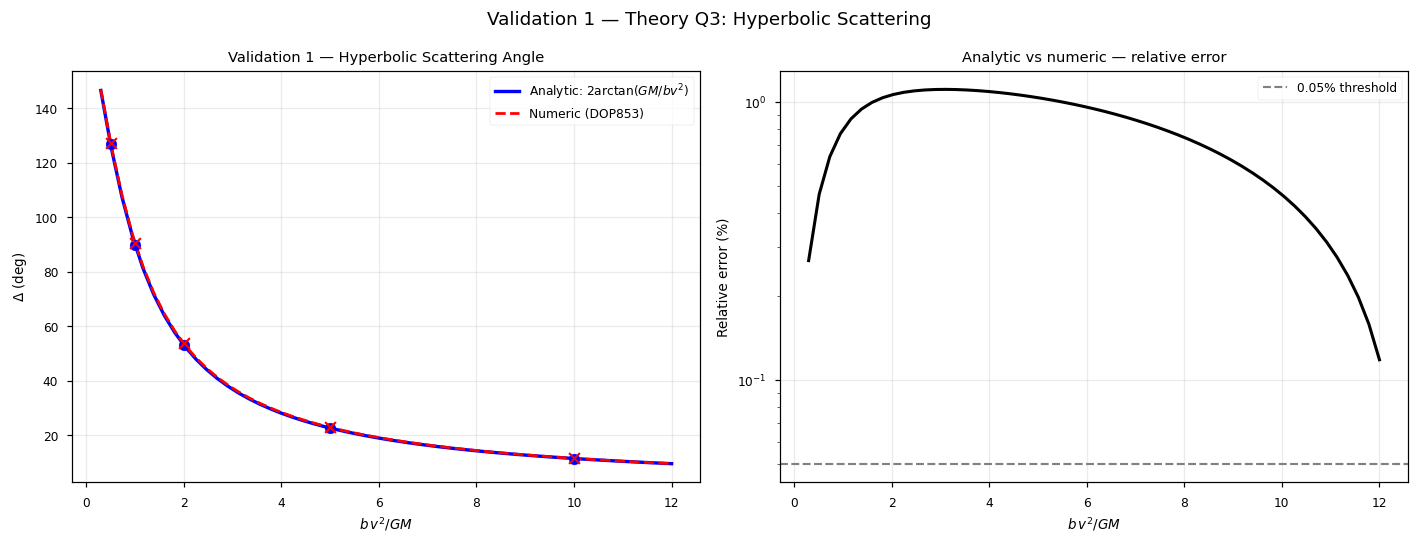

Max error over sweep: 1.1119%


In [11]:
\
def analytic_delta(bn):
    return np.degrees(2 * np.arctan(1.0 / bn))

def numeric_delta(bn, r0=80.0):
    y0 = [r0, bn, -1.0, 0.0]  # GM=v_inf=1

    def eom(t, y):
        x, yc, vx, vy = y
        r3 = (x**2 + yc**2)**1.5
        return [vx, vy, -x/r3, -yc/r3]

    def exit_ev(t, y):
        return np.hypot(y[0], y[1]) - r0
    exit_ev.terminal = True; exit_ev.direction = +1

    sol = solve_ivp(eom, [0, 5e4], y0, events=exit_ev,
                    method='DOP853', rtol=1e-10, atol=1e-13, max_step=0.3)
    if sol.t_events[0].size == 0:
        return np.nan
    vx_f, vy_f = sol.y_events[0][0][2:4]
    return np.degrees(np.arccos(np.clip(
        np.dot([-1,0],[vx_f,vy_f])/np.hypot(vx_f,vy_f), -1, 1)))

b_pts = [0.5, 1.0, 2.0, 5.0, 10.0]
print(f"{'bn':>8}  {'Analytic':>12}  {'Numeric':>12}  {'Rel err':>10}")
print('─'*48)
an_l, nu_l = [], []
for bn in b_pts:
    da = analytic_delta(bn); dn = numeric_delta(bn)
    an_l.append(da); nu_l.append(dn)
    print(f"{bn:>8.1f}  {da:>12.4f}  {dn:>12.4f}  {abs(da-dn)/da*100:>9.4f}%")

b_sw = np.linspace(0.3, 12, 55)
da_sw = [analytic_delta(b) for b in b_sw]
dn_sw = [numeric_delta(b)  for b in b_sw]
err_sw = [abs(da-dn)/da*100 for da,dn in zip(da_sw,dn_sw) if not np.isnan(dn)]
b_sw_v = [b for b,dn in zip(b_sw,dn_sw) if not np.isnan(dn)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.plot(b_sw, da_sw, 'b-', lw=2.2, label=r'Analytic: $2\arctan(GM/bv^2)$')
ax1.plot(b_sw, dn_sw, 'r--', lw=1.8, label='Numeric (DOP853)')
ax1.scatter(b_pts, an_l, color='blue', s=50, zorder=5)
ax1.scatter(b_pts, nu_l, color='red',  s=50, marker='x', zorder=5)
ax1.set_xlabel(r'$b\,v^2/GM$'); ax1.set_ylabel(r'$\Delta$ (deg)')
ax1.set_title('Validation 1 — Hyperbolic Scattering Angle')
ax1.legend(); ax1.grid(alpha=0.25)

ax2.semilogy(b_sw_v, err_sw, 'k-', lw=2)
ax2.axhline(0.05, color='gray', ls='--', label='0.05% threshold')
ax2.set_xlabel(r'$b\,v^2/GM$'); ax2.set_ylabel('Relative error (%)')
ax2.set_title('Analytic vs numeric — relative error')
ax2.legend(); ax2.grid(alpha=0.25)

plt.suptitle('Validation 1 — Theory Q3: Hyperbolic Scattering', fontsize=12)
plt.tight_layout()
plt.savefig('output/validation_scattering.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Max error over sweep: {max(err_sw):.4f}%")

---
## Numerical Validation 2 — Hohmann Transfer (Theory Q4)

Analytical vis-viva equations vs. DOP853 propagation of the heliocentric orbit.
Spacecraft initialised at $(R_E, 0)$ with velocity $v_E + \Delta v_1$.

Analytical (vis-viva + Kepler III):
  v_Earth    = 29.7882 km/s
  v_Jupiter  = 13.0630 km/s
  dv1        = 8.7921 km/s
  dv2        = 5.6437 km/s
  t_transfer = 2.7288 yr

Numerical (DOP853, aphelion detected via dr/dt=0):
  t_transfer = 2.7288 yr
  r_aphelion = 5.20000 AU  (target 5.20000)
  v_arrival  = 7.4193 km/s  (analytic 7.4193)

Quantity                   Analytic      Numeric        Err
----------------------------------------------------------
t_transfer (yr)             2.72882      2.72882   0.00000%
r_aphelion (AU)             5.20000      5.20000   0.00000%
v_arrival (km/s)            7.41929      7.41929   0.00000%


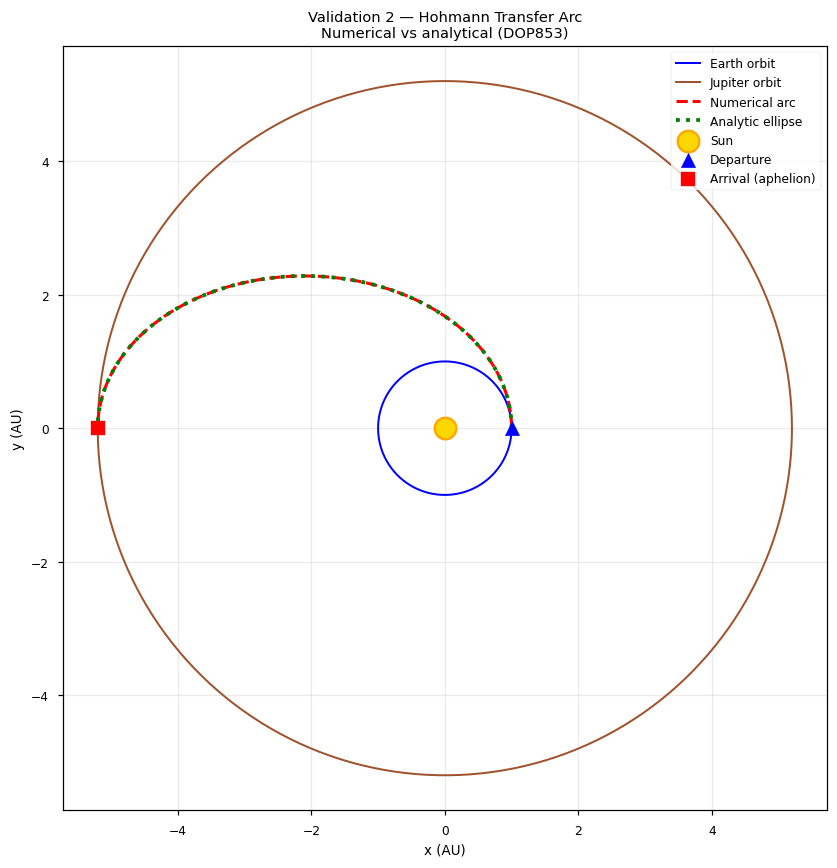

Validation 2 complete.


In [12]:
G_SI = 6.674e-11; M_s = 1.989e30; AU = 1.496e11; yr = 365.25*86400
GM = G_SI * M_s
RE = 1.0*AU; RJ = 5.2*AU
aT = (RE+RJ)/2

vE   = np.sqrt(GM/RE)
vJc  = np.sqrt(GM/RJ)
vp   = np.sqrt(2*GM*RJ/(RE*(RE+RJ)))
va   = np.sqrt(2*GM*RE/(RJ*(RE+RJ)))
dv1  = vp - vE
t_an = np.pi * np.sqrt(aT**3/GM)

print("Analytical (vis-viva + Kepler III):")
print(f"  v_Earth    = {vE/1e3:.4f} km/s")
print(f"  v_Jupiter  = {vJc/1e3:.4f} km/s")
print(f"  dv1        = {dv1/1e3:.4f} km/s")
print(f"  dv2        = {(vJc-va)/1e3:.4f} km/s")
print(f"  t_transfer = {t_an/yr:.4f} yr")

def helio_eom(t, y):
    x, yc, vx, vy = y
    r3 = (x**2+yc**2)**1.5
    return [vx, vy, -GM*x/r3, -GM*yc/r3]

# Event: radial velocity = 0 at aphelion (dr/dt changes sign from + to -)
def rdot_zero(t, y):
    x, yc, vx, vy = y
    r = np.sqrt(x**2+yc**2)
    return (x*vx + yc*vy) / r
rdot_zero.terminal = True
rdot_zero.direction = -1   # dr/dt: positive -> negative at aphelion

sol = solve_ivp(helio_eom, [0, 3*yr], [RE, 0.0, 0.0, vE+dv1],
                events=rdot_zero, method='DOP853',
                rtol=1e-11, atol=1e-13, max_step=yr/300)
t_num = sol.t_events[0][0]
r_fin = np.sqrt(sol.y_events[0][0][0]**2 + sol.y_events[0][0][1]**2)
v_fin = np.sqrt(sol.y_events[0][0][2]**2 + sol.y_events[0][0][3]**2)

print(f"\nNumerical (DOP853, aphelion detected via dr/dt=0):")
print(f"  t_transfer = {t_num/yr:.4f} yr")
print(f"  r_aphelion = {r_fin/AU:.5f} AU  (target {RJ/AU:.5f})")
print(f"  v_arrival  = {v_fin/1e3:.4f} km/s  (analytic {va/1e3:.4f})")

print(f"\n{'Quantity':<22} {'Analytic':>12} {'Numeric':>12} {'Err':>10}")
print('-'*58)
for lbl, va_v, vn_v in [('t_transfer (yr)', t_an/yr, t_num/yr),
                          ('r_aphelion (AU)', RJ/AU,   r_fin/AU),
                          ('v_arrival (km/s)', va/1e3, v_fin/1e3)]:
    print(f"{lbl:<22} {va_v:>12.5f} {vn_v:>12.5f} {abs(va_v-vn_v)/abs(va_v)*100:>9.5f}%")

fig, ax = plt.subplots(figsize=(8, 8))
tc = np.linspace(0, 2*np.pi, 400)
ax.plot(RE/AU*np.cos(tc), RE/AU*np.sin(tc), 'b-',  lw=1.3, label='Earth orbit')
ax.plot(RJ/AU*np.cos(tc), RJ/AU*np.sin(tc), color='sienna', lw=1.3, label='Jupiter orbit')
ax.plot(sol.y[0]/AU, sol.y[1]/AU, 'r--', lw=2, label='Numerical arc')
ecc = (RJ-RE)/(RJ+RE)
th_e = np.linspace(0, np.pi, 200)
r_e  = aT*(1-ecc**2)/(1+ecc*np.cos(th_e))
ax.plot(r_e/AU*np.cos(th_e), r_e/AU*np.sin(th_e), 'g:', lw=2.5, label='Analytic ellipse')
ax.scatter([0],[0], color='gold', s=200, zorder=5, edgecolors='orange', lw=1.5, label='Sun')
ax.scatter([RE/AU],[0], color='blue', marker='^', s=90, zorder=6, label='Departure')
ax.scatter([-RJ/AU],[0], color='red', marker='s', s=90, zorder=6, label='Arrival (aphelion)')
ax.set_xlabel('x (AU)'); ax.set_ylabel('y (AU)')
ax.set_title('Validation 2 — Hohmann Transfer Arc\nNumerical vs analytical (DOP853)')
ax.set_aspect('equal'); ax.legend(fontsize=8); ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('output/validation_hohmann.png', dpi=120, bbox_inches='tight')
plt.show()
print("Validation 2 complete.")

---
## Computational Environment

In [13]:
\
import sys, numpy, scipy, matplotlib, cv2, pandas
print(f"Python     : {sys.version.split()[0]}")
print(f"NumPy      : {numpy.__version__}")
print(f"SciPy      : {scipy.__version__}")
print(f"Matplotlib : {matplotlib.__version__}")
print(f"OpenCV     : {cv2.__version__}")
print(f"Pandas     : {pandas.__version__}")

Python     : 3.13.2
NumPy      : 2.2.5
SciPy      : 1.14.1
Matplotlib : 3.8.4
OpenCV     : 4.11.0
Pandas     : 2.3.2
